# generate results for Fig. 2

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 10
import matplotlib.colors as mcolors

import seaborn as sns

import palettable.colorbrewer.sequential as palet

import time
start_time = time.time()
print(time.ctime())

from dynamic_stock_model import DynamicStockModel

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

Sun Aug  2 15:54:16 2026


- population (million persons)

In [2]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop.head(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
1900,400.265000,44.103,278.2490,76.391,527.86193,1326.869930
1901,402.520077,44.662,280.5497,77.888,532.84672,1338.466497


In [3]:
Materials = ['Cobalt','Nickel','Copper']

IEA_Scenarios = ['STEPS','APS','NZES']

Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Primary_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All carriers-driven']
Secondary_Scenarios = ['Constant','High']
Process_Scenarios = ['Constant','Efficient']
Lifetime_Scenarios = ['Constant','Longer']

Segment_Scenarios = ['Baseline']
#Segment_Scenarios = ['Baseline','Smaller','Larger']

Battery_Sizes = ['Larger']
#Battery_Sizes = ['Constant','Larger']

Battery_Scenarios = ['Baseline','NMC', 'NMA', 'LFP/LMFP', 'Na-ion']

Mining_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All Carrier-driven']
Mining_Sources = ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']

Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

## Demand: Bottom-up (Future use)

In [4]:
Year_Min = 2025

def full_fill(df):
    df_temp = pd.DataFrame(index=np.arange(Year_Min,df.index.min()), columns=df.columns)
    df_temp.fillna(value=0, inplace=True)
    df_output  = pd.concat([df_temp, df])
    
    return df_output

- ESS (kt)

In [5]:
df_ESS_stock = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_stock', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_stock = df_ESS_stock.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_stock = df_ESS_stock.T
df_ESS_stock = full_fill(df_ESS_stock)

df_ESS_inflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_inflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_inflow = df_ESS_inflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_inflow = df_ESS_inflow.T
df_ESS_inflow = full_fill(df_ESS_inflow)

df_ESS_outflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_outflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_outflow = df_ESS_outflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_outflow = df_ESS_outflow.T
df_ESS_outflow = full_fill(df_ESS_outflow)

df_ESS_inflow.head(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

Material            Cobalt                                                    \
ESS Scenario           APS                                                     
Battery Scenario  Baseline            LFP/LMFP                 NMA             
Lifetime          Constant    Longer  Constant    Longer  Constant    Longer   
2010              0.090164  0.090164  0.090164  0.090164  0.090164  0.090164   
2011              0.037165  0.037165  0.037165  0.037165  0.037165  0.037165   

Material                                                  ...    Nickel  \
ESS Scenario                                              ...     STEPS   
Battery Scenario       NMC              Na-ion            ...  LFP/LMFP   
Lifetime          Constant    Longer  Constant    Longer  ...  Constant   
2010              0.090164  0.090164  0.090164  0.090164  ...  0.266726   
2011              0.037165  0.037165  0.037165  0.037165  ...  0.109941   

Material                                                                      \
ESS Scenario                                                                   
Battery Scenario                 NMA                 NMC              Na-ion   
Lifetime            Longer  Constant    Longer  Constant    Longer  Constant   
2010              0.266726  0.266726  0.266726  0.266726  0.266726  0.266726   
2011              0.109941  0.109941  0.109941  0.109941  0.109941  0.109941   

Material                                        
ESS Scenario                                    
Battery Scenario           Optimized            
Lifetime            Longer  Constant    Longer  
2010              0.266726  0.266726  0.266726  
2011              0.109941  0.109941  0.109941  

[2 rows x 108 columns]

- vehicle: battery material (kt)

In [6]:
df_EV_stock = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_stock', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_stock = df_EV_stock.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_stock = df_EV_stock.T
df_EV_stock = full_fill(df_EV_stock)

df_EV_inflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_inflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_inflow = df_EV_inflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_inflow = df_EV_inflow.T
df_EV_inflow = full_fill(df_EV_inflow)

df_EV_outflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_outflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_outflow = df_EV_outflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_outflow = df_EV_outflow.T
df_EV_outflow = full_fill(df_EV_outflow)

df_EV_outflow.head(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will n

Material               Cobalt                                          \
Powertrain Scenario       APS                                           
Segment Scenario     Baseline                                           
Battery Size           Larger                                           
Battery Scenario     Baseline            LFP/LMFP                 NMA   
Lifetime             Constant    Longer  Constant    Longer  Constant   
2005                 0.000006  0.000006  0.000006  0.000006  0.000006   
2006                 0.000020  0.000020  0.000020  0.000020  0.000020   

Material                                                               ...  \
Powertrain Scenario                                                    ...   
Segment Scenario                                                       ...   
Battery Size                                                           ...   
Battery Scenario                    NMC              Na-ion            ...   
Lifetime               Longer  Constant    Longer  Constant    Longer  ...   
2005                 0.000006  0.000006  0.000006  0.000006  0.000006  ...   
2006                 0.000020  0.000020  0.000020  0.000020  0.000020  ...   

Material               Nickel                                          \
Powertrain Scenario     STEPS                                           
Segment Scenario     Baseline                                           
Battery Size           Larger                                           
Battery Scenario     LFP/LMFP                 NMA                 NMC   
Lifetime             Constant    Longer  Constant    Longer  Constant   
2005                 0.000009  0.000009  0.000009  0.000009  0.000009   
2006                 0.000029  0.000029  0.000029  0.000029  0.000029   

Material                                                               
Powertrain Scenario                                                    
Segment Scenario                                                       
Battery Size                                                           
Battery Scenario                 Na-ion           Optimized            
Lifetime               Longer  Constant    Longer  Constant    Longer  
2005                 0.000009  0.000009  0.000009  0.000009  0.000009  
2006                 0.000029  0.000029  0.000029  0.000029  0.000029  

[2 rows x 108 columns]

## Copper cycle

In [7]:
Cu_Sectors = ['Building & Construction','Infrastructure','Transport','Industrial Equipment','Other Products']

Cu_New_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)', 'B-ESS', 'B-EVs']
Cu_Old_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)']
Cu_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','B-CEs','B-EVs','B-ESS',]

Cu_sector_color_dict = {'Building & Construction': '#C6DBEF', 
                     'Infrastructure': '#9ECAE1', 
                     'Building & Infrastructure': '#C6DBEF', 
                     
                     'Transport': '#6BAED6', 
                     'Transport (Exclude B-EVs)': '#6BAED6', 
                     'Transportation': '#6BAED6', 
                     
                     'Industrial Equipment': '#3182BD',
                     
                     'Other Products':'#08519C',  
                     'Other Products (Exclude B-ESS)':'#08519C',
                     
                     'B-CEs': '#FDAE6B',
                     'B-EVs': '#F16913',
                     'B-ESS': '#8C2D04'}

Cu_New_Sector_Colors = [Cu_sector_color_dict[s] for s in Cu_New_Sectors]
Cu_Agg_Sector_Colors = [Cu_sector_color_dict[s] for s in Cu_Agg_Sectors]

- Copper per capita stock (kg/person)

In [8]:
df_Cu_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Cu_per_capita = df_Cu_per_capita.loc[:2050:]
df_Cu_per_capita.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),Total
Sector,,,,,,
2049,51.025553,18.937606,7.981351,8.650224,7.054912,93.649647
2050,51.235015,19.378207,8.327024,8.856932,7.322852,95.120030


- lifetime

In [9]:
df_Cu_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Cu_lifetime = df_Cu_lifetime.T
df_Cu_lifetime.head(2)

Lifetime Scenario                Constant                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
1900                                 40.0           34.0   NaN      17.0   
1901                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
1900                                   17.0                 17.0   NaN   
1901                                   17.0                 17.0   NaN   

Lifetime Scenario                                                \
Sector            Other Products Other Products (Exclude B-ESS)   
1900                        13.0                           13.0   
1901                        13.0                           13.0   

Lifetime Scenario                  Longer                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
1900                                 40.0           34.0   NaN      17.0   
1901                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
1900                                   17.0                 17.0   NaN   
1901                                   17.0                 17.0   NaN   

Lifetime Scenario                                                
Sector            Other Products Other Products (Exclude B-ESS)  
1900                        13.0                           13.0  
1901                        13.0                           13.0

- Copper Traditional use 
- stock, inflow, outflow
- million persons * kg/person = kt

In [10]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt, Old_Sectors):
    
    df_stock = pd.DataFrame(index=df_capita.index, 
                             columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            df_stock[(lt,s)] = df_pop['World'] * df_capita[s]
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(lt,s)] = DSM.i
            df_outflow[(lt,s)] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, 
                              columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_outflow_2 = df_stock_2.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            ## inflow-driven
            DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                    i = list(df_inflow_2[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()
            ## fill in 
            df_stock_2[(lt,s)] = DSM.s
            df_outflow_2[(lt,s)] = DSM.o
                
    return df_stock_2, df_inflow_2, df_outflow_2


df_Cu_traditional_stock, df_Cu_traditional_inflow, df_Cu_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Cu_per_capita, df_Cu_lifetime, Cu_Old_Sectors)
df_Cu_traditional_stock = df_Cu_traditional_stock.loc[Year_Min:,:]
df_Cu_traditional_inflow = df_Cu_traditional_inflow.loc[Year_Min:,:]
df_Cu_traditional_outflow = df_Cu_traditional_outflow.loc[Year_Min:,:]
df_Cu_traditional_inflow.head(2)

Lifetime                Constant                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2025                 9289.358031    3494.316231               2287.131327   
2026                 9171.777626    3542.086418               2344.233269   

Lifetime                                                      \
Sector   Industrial Equipment Other Products (Exclude B-ESS)   
Sector                                                         
2025              2877.911034                    2558.271193   
2026              2942.644061                    2629.279972   

Lifetime                  Longer                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2025                 9289.332077    3494.306335               2287.120192   
2026                 9171.704965    3542.054976               2344.178537   

Lifetime                                                      
Sector   Industrial Equipment Other Products (Exclude B-ESS)  
Sector                                                        
2025              2877.892932                    2558.248508  
2026              2942.564473                    2629.161311

- dissipation loss rate

In [11]:
df_Cu_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Cu_dissipation_rate

,Dissipation rate
Sector,
Building & Construction,0.002
Infrastructure,0.006
Transport,0.004
Transport (Exclude B-EVs),0.004
B-EVs,0.004
Industrial Equipment,0.000
Other Products,0.020
Other Products (Exclude B-ESS),0.020
B-ESS,0.020


- loss rate

In [12]:
df_Cu_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Cu_parameters = df_Cu_parameters.T
df_Cu_parameters = df_Cu_parameters.loc[Year_Min:,:]
df_Cu_parameters.head(2)

Scenario          Constant                                            \
Loss rate mining loss rate benefication loss rate smelting loss rate   
2025               0.06945                 0.1346             0.0129   
2026               0.06945                 0.1346             0.0129   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2025                  0.0051                         0.06   
2026                  0.0051                         0.06   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2025                         0.17                      0.92   
2026                         0.17                      0.92   

Scenario                                                        Efficient  \
Loss rate old scrap collection rate recycling efficiency mining loss rate   
2025                           0.45                 0.92         0.065977   
2026                           0.45                 0.92         0.062679   

Scenario                                                                \
Loss rate benefication loss rate smelting loss rate refining loss rate   
2025                    0.127870           0.012255           0.004845   
2026                    0.121476           0.011642           0.004603   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2025                           0.05700                0.161500   
2026                           0.05415                0.153425   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2025                       0.929200                  0.454500   
2026                       0.938492                  0.459045   

Scenario                        
Loss rate recycling efficiency  
2025                  0.929200  
2026                  0.938492

- scrap ratio

In [13]:
df_Cu_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_Cu_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,0.90
Clean scrap ratio of old scrap,0.33


## Nickel cycle

In [14]:
Ni_Sectors = ['Building & Infrastructure','Transportation','Industrial Machinery','Applications & Electronics','Metal Goods & Others']
Ni_New_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others','B-ESS','B-EVs']
Ni_Old_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others']
Ni_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

Ni_sector_color_dict = {'Building & Infrastructure': '#C6DBEF', 
                        
                    'Transportation': '#6BAED6', 
                    'Transportation (Exclude B-EVs)': '#6BAED6', 
                        
                    'Industrial Machinery': '#3182BD', 
                    'Industrial Equipment': '#3182BD', 
                        
                    'Applications & Electronics':'#31A354', 
                    'Applications & Electronics (Exclude B-ESS)':'#31A354', 
                        
                    'Metal Goods & Others':'#08519C', 
                        
                    'Power Plant': '#BCBDDC',
                     
                    'B-CEs': '#FDAE6B',
                    'B-EVs': '#F16913',
                    'B-ESS': '#8C2D04',}


Ni_New_Sector_Colors = [Ni_sector_color_dict[s] for s in Ni_New_Sectors]
Ni_Agg_Sector_Colors = [Ni_sector_color_dict[s] for s in Ni_Agg_Sectors]

- Nickel per capita (kg/person)

In [15]:
df_Ni_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Ni_per_capita = df_Ni_per_capita.loc[:2050:]
df_Ni_per_capita.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,Total
Sector,,,,,,
2049,2.224502,2.250602,4.045783,1.158639,2.101553,11.781080
2050,2.260995,2.301909,4.094573,1.175339,2.173898,12.006714


- lifetime

In [16]:
df_Ni_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Ni_lifetime = df_Ni_lifetime.T
df_Ni_lifetime.head(2)

Scenario                  Constant                 \
Sector   Building & Infrastructure Transportation   
1900                          30.0           25.0   
1901                          30.0           25.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
1900                               25.0   NaN                 50.0   
1901                               25.0   NaN                 50.0   

Scenario                             \
Sector   Applications & Electronics   
1900                           14.0   
1901                           14.0   

Scenario                                                   \
Sector   Applications & Electronics (Exclude B-ESS) B-ESS   
1900                                           14.0   NaN   
1901                                           14.0   NaN   

Scenario                                         Longer                 \
Sector   Metal Goods & Others Building & Infrastructure Transportation   
1900                     15.0                      50.0           18.0   
1901                     15.0                      50.0           18.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
1900                               18.0   NaN                 25.0   
1901                               18.0   NaN                 25.0   

Scenario                             \
Sector   Applications & Electronics   
1900                           15.0   
1901                           15.0   

Scenario                                                                        
Sector   Applications & Electronics (Exclude B-ESS) B-ESS Metal Goods & Others  
1900                                           15.0   NaN                 15.0  
1901                                           15.0   NaN                 15.0

- Nickel Traditional use 
- stock, inflow, outflow
- million persons * kg/person = kt

In [17]:
df_Ni_traditional_stock, df_Ni_traditional_inflow, df_Ni_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Ni_per_capita, df_Ni_lifetime, Ni_Old_Sectors)
df_Ni_traditional_stock = df_Ni_traditional_stock.loc[Year_Min:,:]
df_Ni_traditional_inflow = df_Ni_traditional_inflow.loc[Year_Min:,:]
df_Ni_traditional_outflow = df_Ni_traditional_outflow.loc[Year_Min:,:]
df_Ni_traditional_inflow.tail(2)

Lifetime                  Constant                                 \
Sector   Building & Infrastructure Transportation (Exclude B-EVs)   
Sector                                                              
2049                    896.122979                    1107.113630   
2050                    911.254961                    1131.030942   

Lifetime                                                                  \
Sector   Industrial Machinery Applications & Electronics (Exclude B-ESS)   
Sector                                                                     
2049               995.646879                                 825.986729   
2050              1010.920424                                 841.377391   

Lifetime                                         Longer  \
Sector   Metal Goods & Others Building & Infrastructure   
Sector                                                    
2049              1626.748474                868.497251   
2050              1690.842975                878.312385   

Lifetime                                                      \
Sector   Transportation (Exclude B-EVs) Industrial Machinery   
Sector                                                         
2049                        1050.989459            990.31210   
2050                        1065.464498           1004.50762   

Lifetime                                                                  
Sector   Applications & Electronics (Exclude B-ESS) Metal Goods & Others  
Sector                                                                    
2049                                     720.975036          1462.726610  
2050                                     730.148879          1512.541069

- dissipation loss rate

In [18]:
df_Ni_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Ni_dissipation_rate.fillna(0, inplace=True)
df_Ni_dissipation_rate

,Dissipation rate
Sector,
Building & Infrastructure,0.0001
Transportation,0.0001
Transportation (Exclude B-EVs),0.0001
B-EVs,0.0001
Industrial Machinery,0.0000
Applications & Electronics,0.0000
Applications & Electronics (Exclude B-ESS),0.0000
B-ESS,0.0000
Metal Goods & Others,0.0050


- loss rate

In [19]:
df_Ni_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Ni_parameters = df_Ni_parameters.T
df_Ni_parameters = df_Ni_parameters.loc[Year_Min:,:]
df_Ni_parameters.head(2)

Scenario          Constant                                        \
Loss rate mining loss rate smelting loss rate refining loss rate   
2025              0.143398           0.056408           0.043997   
2026              0.143398           0.056408           0.043997   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2025                              0.21                    0.14   
2026                              0.21                    0.14   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2025                           0.86                      0.63   
2026                           0.86                      0.63   

Scenario                              Efficient                     \
Loss rate recycling efficiency mining loss rate smelting loss rate   
2025                       1.0         0.136228           0.053588   
2026                       1.0         0.129417           0.050908   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2025                0.041797                     0.199500   
2026                0.039707                     0.189525   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2025                      0.13300                  0.868600   
2026                      0.12635                  0.877286   

Scenario                                                  
Loss rate old scrap collection rate recycling efficiency  
2025                       0.636300                  1.0  
2026                       0.642663                  1.0

- scrap ratio

In [20]:
df_Ni_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_Ni_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,1.000000
Clean scrap ratio of old scrap,0.981333


## Cobalt cycle

In [21]:
Co_Sectors = ['Battery','S&A','C&C','MAG','CAT','PI&E','OTH']
Co_New_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs','B-ESS','B-EVs']
Co_Old_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs']
Co_Agg_Sectors = ['Metal Goods & Others','B-CEs','B-EVs','B-ESS']

Co_sector_color_dict = {'S&A': '#FDD0A2',
                     'C&C': '#FDAE6B',
                     'MAG': '#FD8D3C',
                     'CAT': '#F16913',
                     'PI&E': '#D94801',
                     'OTH': '#8C2D04', 
                     
                     'Metal Goods & Others':'#08519C',
                     
                     'B-CEs': '#FDAE6B',
                    'B-EVs': '#F16913',
                    'B-ESS': '#8C2D04', }

Co_New_Sector_Colors = [Co_sector_color_dict[s] for s in Co_New_Sectors]
Co_Agg_Sector_Colors = [Co_sector_color_dict[s] for s in Co_Agg_Sectors]

- lifetime

In [22]:
df_Co_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=[2])
df_Co_lifetime = df_Co_lifetime.T
df_Co_lifetime.head(2)

Lifetime Constant                                                  Longer  \
Sector    Battery B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH Battery   
1988          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   
1989          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   

Lifetime                                                  
Sector   B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH  
1988       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0  
1989       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0

- Cobalt per capita (kg/1000 persons)

In [23]:
df_Co_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Co_per_capita.head(2)

,B-CEs,S&A,C&C,MAG,CAT,PI&E,OTH,Total
Sector,,,,,,,,
1988,0.767447,0.948708,0.521633,0.335234,0.323229,0.398726,1.109249,4.404226
1989,1.465547,1.820370,0.746412,0.643243,0.620410,0.765071,1.587239,7.648293


- Cobalt Traditional use 
- stock, inflow, outflow
- million persons * kg/1000 persons = t
- from t to kt

In [24]:
df_Co_traditional_stock, df_Co_traditional_inflow, df_Co_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Co_per_capita, df_Co_lifetime, Co_Old_Sectors)

df_Co_traditional_stock = df_Co_traditional_stock / 1e3  # from t to kt 
df_Co_traditional_inflow = df_Co_traditional_inflow / 1e3  # from t to kt 
df_Co_traditional_outflow = df_Co_traditional_outflow / 1e3  # from t to kt 

df_Co_traditional_stock = df_Co_traditional_stock.loc[Year_Min:,:]
df_Co_traditional_inflow = df_Co_traditional_inflow.loc[Year_Min:,:]
df_Co_traditional_outflow = df_Co_traditional_outflow.loc[Year_Min:,:]
df_Co_traditional_inflow.head(2)

Lifetime   Constant                                                     \
Sector          S&A        C&C       MAG       CAT      PI&E       OTH   
Sector                                                                   
2025      20.515316  13.898023  6.036324  7.385298  7.810709  7.784252   
2026      21.935407  14.356479  5.945936  7.450327  7.727639  7.984319   

Lifetime                Longer                                           \
Sector        B-CEs        S&A        C&C       MAG       CAT      PI&E   
Sector                                                                    
2025      77.513555  20.513936  13.724184  6.036063  7.384935  7.810313   
2026      73.702939  21.920745  14.082430  5.942845  7.446708  7.723154   

Lifetime                       
Sector         OTH      B-CEs  
Sector                         
2025      7.684163  77.489229  
2026      7.832235  73.361048

In [25]:
df_Co_traditional_inflow.tail(2)

Lifetime  Constant                                                         \
Sector         S&A        C&C        MAG        CAT       PI&E        OTH   
Sector                                                                      
2049      61.92074  30.418709  11.716639  12.278807  13.390125  12.170797   
2050      62.16483  30.539208  11.764195  12.331159  13.444286  12.216947   

Lifetime                 Longer                                             \
Sector         B-CEs        S&A        C&C       MAG        CAT       PI&E   
Sector                                                                       
2049      138.780657  50.593974  25.351530  9.563650  10.053514  10.930543   
2050      139.262225  50.364001  25.288849  9.522207  10.004073  10.882635   

Lifetime                         
Sector          OTH       B-CEs  
Sector                           
2049      10.143008  113.262851  
2050      10.116422  112.663952

- loss rate

In [26]:
df_Co_loss_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='loss rate', index_col=[0,1,2], header=[2])
df_Co_loss_rate = df_Co_loss_rate.T
df_Co_loss_rate = df_Co_loss_rate.loc[Year_Min:,:]
df_Co_loss_rate.head(2)

Scenario  Constant                                                             \
Stage       Mining Refining Manufacturing                                       
Loss rate      All      All       Battery B-EVs B-ESS B-CEs   S&A   C&C   MAG   
2025          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   
2026          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   

Scenario         ...     Efficient                                        \
Stage            ... Manufacturing                                         
Loss rate   CAT  ...       Battery     B-EVs     B-ESS     B-CEs     S&A   
2025       0.05  ...      0.009900  0.009900  0.009900  0.009900  0.1520   
2026       0.05  ...      0.009801  0.009801  0.009801  0.009801  0.1444   

Scenario                                                     
Stage                                                        
Loss rate       C&C       MAG       CAT      PI&E       OTH  
2025       0.009900  0.019800  0.049500  0.009900  0.009900  
2026       0.009801  0.019602  0.049005  0.009801  0.009801  

[2 rows x 24 columns]

- recycling rate

In [27]:
df_Co_recycling_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='recycling rate', index_col=[0,1,2], header=[2])
df_Co_recycling_rate = df_Co_recycling_rate.T
df_Co_recycling_rate = df_Co_recycling_rate.loc[Year_Min:,:]
df_Co_recycling_rate.head(2)

Scenario                   Constant                                         \
Recycling New scrap generation rate                                          
Sector                      Battery B-EVs B-ESS B-CEs   S&A  C&C  MAG  CAT   
2025                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   
2026                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   

Scenario             ...               High                             \
Recycling            ... EoL recycling rate                              
Sector    PI&E  OTH  ...            Battery    B-EVs    B-ESS    B-CEs   
2025       0.0  0.0  ...            0.80800  0.80800  0.80800  0.10100   
2026       0.0  0.0  ...            0.81608  0.81608  0.81608  0.10201   

Scenario                                              
Recycling                                             
Sector         S&A       C&C      MAG  CAT PI&E  OTH  
2025       0.80800  0.454500  0.10100  0.0  0.0  0.0  
2026       0.81608  0.459045  0.10201  0.0  0.0  0.0  

[2 rows x 60 columns]

- Surplus

In [28]:
df_Co_Surplus = pd.read_excel(file_path + r'Sector_Cu_Ni_Co\World\by-Cobalt_compile_data_world.xlsx', sheet_name='Surplus', index_col=[0], header=[3])
df_Co_Surplus.fillna(value=0, inplace=True)
df_Co_Surplus = df_Co_Surplus / 1000  ## from ton to kt
df_Co_Surplus.loc[2020:2025]

,Cobalt surplus,Battery surplus
2020,0.0,0.0
2021,0.0,0.0
2022,0.0,14.2
2023,0.0,25.0
2024,0.0,36.0
2025,0.0,0.0


## By production

In [29]:
df_Primary_Baseline = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Baseline', header=1, index_col=[0])
df_Primary_Baseline = df_Primary_Baseline / 1e3  ## from t to kt
df_Primary_Baseline = df_Primary_Baseline.loc[Year_Min:,:]
df_Primary_Baseline.head(2)

,Total,Cobalt_from_Cobalt,Cobalt_from_Copper,Cobalt_from_Sulfide_Nickel,Cobalt_from_Laterite_Nickel
Year,,,,,
2025,288.869319,13.026317,239.719868,9.599075,26.524059
2026,304.828360,13.909072,252.908321,11.052875,26.958092


In [30]:
df_Nickel_Source = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Nickel', header=2, index_col=[0])
df_Nickel_Source = df_Nickel_Source.loc[Year_Min:,:]
df_Nickel_Source.head(2)

,Sulfide Nickel,Laterite Nickel
Year,,
2025,0.272581,0.727419
2026,0.269677,0.730323


In [31]:
df_IEA_prod_capacity = pd.read_excel(file_path + 'Sector_Mining/Cu_Ni_mining_capacity.xlsx', sheet_name='Mining', index_col=[0], header=2)
df_IEA_prod_capacity = df_IEA_prod_capacity.loc[Year_Min:,:]
df_IEA_prod_capacity

,Cobalt_SP,Cobalt,Nickel,Copper
Year,,,,
2025,288.869319,281.233333,3965.966667,23040.166667
2026,304.828360,289.126667,4070.933333,23286.333333
2027,318.111089,297.020000,4175.900000,23532.500000
2028,335.945150,304.913333,4280.866667,23778.666667
2029,349.494977,312.806667,4385.833333,24024.833333
2030,348.012589,320.700000,4490.800000,24271.000000
2031,336.049318,307.910000,4486.600000,23360.600000
2032,303.384701,295.120000,4482.400000,22450.200000
2033,319.012541,282.330000,4478.200000,21539.800000


## All Scenarios
- All inflows, outflows, stocks (kt)
### 人工测试

In [32]:
def rename_sector(row):
    
    if row.Material == 'Copper':
        if row.Sector in ['B-ESS','B-EVs','Industrial Equipment']:
            return row.Sector
        elif row.Sector in ['Building & Construction', 'Infrastructure']:
            return 'Building & Infrastructure'
        elif row.Sector == 'Transport (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Other Products (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Nickel':
        if row.Sector in ['B-ESS','B-EVs','Building & Infrastructure','Metal Goods & Others']:
            return row.Sector
        elif row.Sector == 'Transportation (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Industrial Machinery':
            return 'Industrial Equipment'
        elif row.Sector == 'Applications & Electronics (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Cobalt':
        if row.Sector in ['B-ESS','B-EVs','B-CEs']:
            return row.Sector
        else:
            return 'Metal Goods & Others'
        
        
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T.reset_index(drop=False)
    
    df.Sector = df.apply(rename_sector, axis=1)
    df = df.groupby(['Material','Sector']).sum().T
    
    return df

In [33]:
def extract_all_sectors(flow, lt, d_sce, seg_sce, b_size, b_sce):
    
    ################################## Copper
    df_copper = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Copper'],Cu_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Cu_Old_Sectors:
        if flow == 'Inflow':
            ## Lifetime, Sector
            df_copper[('Copper',s)] = df_Cu_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_copper[('Copper',s)] = df_Cu_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_copper[('Copper',s)] = df_Cu_traditional_stock[(lt,s)] 
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_copper[('Copper','B-ESS')] = df_ESS_inflow[('Copper',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_copper[('Copper','B-ESS')] = df_ESS_outflow[('Copper',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_copper[('Copper','B-ESS')] = df_ESS_stock[('Copper',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_copper[('Copper','B-EVs')] = df_EV_inflow[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_copper[('Copper','B-EVs')] = df_EV_outflow[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_copper[('Copper','B-EVs')] = df_EV_stock[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
                
    ################################## Nickel
    df_nickel = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Nickel'],Ni_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Ni_Old_Sectors:
        if flow == 'Inflow':
            df_nickel[('Nickel',s)] = df_Ni_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_nickel[('Nickel',s)] = df_Ni_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_nickel[('Nickel',s)] = df_Ni_traditional_stock[(lt,s)]
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_inflow[('Nickel',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_outflow[('Nickel',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_nickel[('Nickel','B-ESS')] = df_ESS_stock[('Nickel',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_inflow[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_outflow[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_nickel[('Nickel','B-EVs')] = df_EV_stock[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    
    ################################## Cobalt
    df_cobalt = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Cobalt'],Co_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Co_Old_Sectors:
        if flow == 'Inflow':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_stock[(lt,s)]
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_inflow[('Cobalt',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_outflow[('Cobalt',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_stock[('Cobalt',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_inflow[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_outflow[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_stock[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
            
    ################################## 
    df_output = pd.concat([df_copper, df_nickel, df_cobalt], axis=1)
    
    return df_output


############################# 人工测试
lt='Constant'
d_sce='NZES'  # IEA_Scenarios = ['STEPS','APS','NZES']
seg_sce='Baseline'
b_size='Larger'
b_sce='Baseline'  # Battery_Scenarios = ['Baseline','LFP/LMFP','NCX low cobalt', 'Next generation']

df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_stock_2 = reconstruct_sector(df_all_sector_stock)

df_all_sector_inflow_2.tail(2)

Material      Cobalt                                               \
Sector         B-CEs      B-ESS        B-EVs Metal Goods & Others   
2049      138.780657  81.544542  2291.246706           141.895818   
2050      139.262225  83.848216  2385.795627           142.460625   

Material       Copper                                                      \
Sector          B-CEs       B-ESS         B-EVs Building & Infrastructure   
2049      6208.680534  502.710057  14125.197580               21665.86790   
2050      6489.182234  516.911872  14708.077716               22191.11272   

Material                                          Nickel              \
Sector   Industrial Equipment Transportation       B-CEs       B-ESS   
2049              5680.291415    6113.698414  825.986729  439.731207   
2050              5856.586270    6444.371010  841.377391  452.153837   

Material                                                               \
Sector           B-EVs Building & Infrastructure Industrial Equipment   
2049      12355.611541                896.122979           995.646879   
2050      12865.469227                911.254961          1010.920424   

Material                                      
Sector   Metal Goods & Others Transportation  
2049              1626.748474    1107.113630  
2050              1690.842975    1131.030942

In [34]:
df_all_sector_inflow['Copper'].tail(2)

Sector,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),B-ESS,B-EVs
2049,13636.470453,8029.397447,6113.698414,5680.291415,6208.680534,502.710057,14125.197580
2050,13895.621879,8295.490841,6444.371010,5856.586270,6489.182234,516.911872,14708.077716


In [35]:
df_all_sector_inflow['Cobalt'].tail(2)

Sector,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs,B-ESS,B-EVs
2049,61.92074,30.418709,11.716639,12.278807,13.390125,12.170797,138.780657,81.544542,2291.246706
2050,62.16483,30.539208,11.764195,12.331159,13.444286,12.216947,139.262225,83.848216,2385.795627


In [36]:
df_all_sector_inflow['Nickel'].tail(2)

Sector,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,B-ESS,B-EVs
2049,896.122979,1107.113630,995.646879,825.986729,1626.748474,439.731207,12355.611541
2050,911.254961,1131.030942,1010.920424,841.377391,1690.842975,452.153837,12865.469227


- Copper primary supply + secondary supply

In [37]:
def cal_world_copper_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce):

    df_inflow = df_all_inflow['Copper'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Copper'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Cu_dissipation_rate.at[sector, 'Dissipation rate'])
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Cu_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Cu_parameters[process_sce,'old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Cu_parameters[process_sce,'manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Cu_parameters[process_sce,'manufacturing loss rate'] * df_Cu_parameters[process_sce,'new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Cu_parameters[process_sce,'recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1-df_Cu_parameters[process_sce,'refining loss rate']) / (1-df_Cu_parameters[process_sce,'smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Cu_parameters[process_sce,'benefication loss rate']) / (1-df_Cu_parameters[process_sce,'mining loss rate'])

    ################ 与统计数据进行比较
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world


df_copper_temp = cal_world_copper_supply(df_all_sector_inflow, df_all_sector_outflow, secondary_sce='Constant', process_sce='Constant')
df_copper_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,20830.340716,16774.631093,20352.651889,21473.480267,12641.857265,5688.835769,4046.328089,5519.011084,3878.860552
2026,21251.416148,17113.722283,20802.117381,21963.482243,13031.074250,5863.983412,4138.660991,5659.909418,3995.316187
2027,22361.184087,18007.416152,21811.042553,22996.691004,13439.710021,6047.869510,4333.352377,5895.814078,4126.575184
2028,23554.358822,18968.277344,22893.498573,24104.176282,13870.987892,6241.944551,4542.039964,6147.677670,4265.402298
2029,24843.094692,20006.093724,24060.787591,25297.624732,14330.269554,6448.621299,4766.925913,6418.278351,4413.487353
2030,26172.339748,21076.532069,25270.902804,26537.604490,14825.540176,6671.493079,5000.579930,6702.114653,4572.361688
2031,26717.814568,21515.801834,25863.809001,27188.029689,15367.175040,6915.228768,5123.141980,6892.853275,4733.876075
2032,27951.869201,22509.583525,27027.164265,28397.861090,15967.156086,7185.220239,5351.115030,7187.126205,4921.272338
2033,29266.296627,23568.089263,28274.390265,29698.397872,16634.679867,7485.605940,5596.180033,7506.811990,5128.976065
2034,30659.655748,24690.158535,29605.284242,31089.926144,17373.106322,7817.897845,5858.390902,7852.458101,5357.924195


- Nickel primary supply + secondary supply

In [38]:
def cal_world_nickel_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce):
    
    df_inflow = df_all_inflow['Nickel'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Nickel'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Ni_dissipation_rate.at[sector, 'Dissipation rate'])
        
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Ni_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Ni_parameters[process_sce,'old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Ni_parameters[process_sce,'manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Ni_parameters[process_sce,'manufacturing loss rate'] * df_Ni_parameters[process_sce,'new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Ni_parameters[process_sce,'recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2'])/ (1-df_Ni_parameters[process_sce,'refining loss rate']) / (1-df_Ni_parameters[process_sce,'smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Ni_parameters[process_sce,'mining loss rate'])

    ################ 与统计数据进行比较
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    
    return df_world


df_nickel_temp = cal_world_nickel_supply(df_all_sector_inflow, df_all_sector_outflow, secondary_sce='Constant', process_sce='Constant')
df_nickel_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,3578.492919,3065.342901,2781.117437,3538.592817,1355.658611,854.064925,495.402994,1333.525374,15.942545
2026,4014.822493,3439.103529,3119.160798,3914.466557,1430.705200,901.344276,548.025318,1432.544501,16.825093
2027,4568.059896,3913.007595,3547.658369,4384.799523,1515.712013,954.898568,613.871933,1550.945728,17.824773
2028,5173.727967,4431.823858,4016.819621,4902.570657,1613.425275,1016.457923,686.359892,1683.843934,18.973881
2029,5841.438411,5003.785719,4534.129898,5478.089101,1728.792501,1089.139276,766.932474,1835.741150,20.330600
2030,6519.239280,5584.391055,5059.537615,6076.963159,1869.700722,1177.911455,850.774842,2006.698616,21.987680
2031,6951.345220,5954.533711,5395.516909,6512.479351,2046.755937,1289.456240,911.747109,2177.133499,24.069850
2032,7482.984663,6409.936929,5808.968690,7052.572377,2271.507395,1431.049659,987.360133,2391.696865,26.712927
2033,8046.455719,6892.607159,6247.681668,7651.506479,2552.743242,1608.228242,1071.210907,2649.418889,30.020261
2034,8636.970624,7398.443196,6707.986199,8307.233694,2893.011041,1822.596956,1163.012717,2951.587863,34.021810


- Cobalt primary supply + secondary supply

In [39]:
def cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce):
    
    df_inflow = df_all_inflow['Cobalt'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Cobalt'].T.groupby(['Sector']).sum().T
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_inflow.index)
    df_world['P4_P5'] = df_inflow.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Co_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] * df_Co_recycling_rate[(secondary_sce,'EoL recycling rate',sector)]
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P3_P2'] = df_world['P6_P3']
    
    ################ 往前算
    df_manu = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_manu_recycle = df_manu.copy()
    for sector in Co_New_Sectors:
        df_manu[sector] = df_inflow[sector] / (1 - df_Co_loss_rate[(process_sce,'Manufacturing',sector)])
        df_manu_recycle[sector] = df_manu[sector] * df_Co_recycling_rate[(secondary_sce,'New scrap generation rate',sector)] * df_Co_recycling_rate[(secondary_sce,'New scrap recycling efficiency',sector)]
        
    df_world['P4_P3'] = df_manu_recycle.sum(axis=1)
    df_world['P3_P4'] = df_world['P4_P3']
    df_world['P2_P4'] = df_manu.sum(axis=1) + df_sur['Battery surplus']
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1 - df_Co_loss_rate[(process_sce,'Refining','All')])
    df_world['P1_P2'] = df_world['P1_P2'] + df_sur['Cobalt surplus'] 
    df_world['L0_P1'] = df_world['P1_P2'] / (1 - df_Co_loss_rate[(process_sce,'Mining','All')])
    
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    
    return df_world
    
    
df_cobalt_temp = cal_world_cobalt_supply(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='Constant', process_sce='Constant')
df_cobalt_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,487.660568,316.979369,287.240919,280.332505,133.312504,33.657423,15.928094,15.928094,33.657423
2026,591.768213,384.649338,345.211256,337.467735,134.296890,37.491785,16.989165,16.989165,37.491785
2027,717.047956,466.081171,415.556317,406.872688,140.372186,42.691380,17.971162,17.971162,42.691380
2028,865.819854,562.782905,500.095562,490.335459,154.185772,49.869238,18.918249,18.918249,49.869238
2029,1029.047576,668.880924,594.457152,583.454749,170.236382,59.352413,20.133560,20.133560,59.352413
2030,1190.848297,774.051393,691.437008,679.067099,188.980064,72.195893,21.753023,21.753023,72.195893
2031,1305.637657,848.664477,769.056888,755.464019,215.817674,90.125306,23.578789,23.578789,90.125306
2032,1429.967702,929.479006,858.171608,843.193129,251.810197,114.588403,25.603375,25.603375,114.588403
2033,1558.050789,1012.733013,957.005836,940.527442,296.621390,146.819426,27.708250,27.708250,146.819426
2034,1689.017720,1097.861518,1065.985624,1047.876973,352.002183,187.696409,29.941573,29.941573,187.696409


In [40]:
def cal_all_metal_demand(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce):
    
    df_copper = cal_world_copper_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce)
    df_copper = df_copper.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_copper.columns = ['Copper_Primary', 'Copper_Secondary_Low','Copper_Secondary_High']  ######################********************
    
    df_nickel = cal_world_nickel_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce)
    df_nickel = df_nickel.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_nickel.columns = ['Nickel_Primary','Nickel_Secondary_Low','Nickel_Secondary_High']  ######################********************

    df_cobalt = cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce)
    df_cobalt = df_cobalt.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_cobalt.columns=['Cobalt_Primary','Cobalt_Secondary_Low','Cobalt_Secondary_High']  ######################********************
    
    df_demand = pd.concat([df_cobalt, df_copper, df_nickel], axis=1)
    
    for m in ['Cobalt','Copper','Nickel']:
        df_demand[m+'_Total'] = df_demand[m+'_Primary'] + df_demand[m+'_Secondary_Low'] + df_demand[m+'_Secondary_High']
        
    #for m in ['Cobalt','Copper','Nickel']:
       # df_demand[m+'_Sec_Share'] = df_demand[m+'_Secondary_Total'] / df_demand[m+'_Total']
    
    return df_demand


df_supply_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='Constant', process_sce='Constant')
df_supply_demand

,Cobalt_Primary,Cobalt_Secondary_Low,Cobalt_Secondary_High,Copper_Primary,Copper_Secondary_Low,Copper_Secondary_High,Nickel_Primary,Nickel_Secondary_Low,Nickel_Secondary_High,Cobalt_Total,Copper_Total,Nickel_Total
2025,316.979369,33.657423,15.928094,16774.631093,3878.860552,5519.011084,3065.342901,15.942545,1333.525374,366.564887,26172.502729,4414.810820
2026,384.649338,37.491785,16.989165,17113.722283,3995.316187,5659.909418,3439.103529,16.825093,1432.544501,439.130288,26768.947888,4888.473123
2027,466.081171,42.691380,17.971162,18007.416152,4126.575184,5895.814078,3913.007595,17.824773,1550.945728,526.743713,28029.805414,5481.778097
2028,562.782905,49.869238,18.918249,18968.277344,4265.402298,6147.677670,4431.823858,18.973881,1683.843934,631.570392,29381.357313,6134.641673
2029,668.880924,59.352413,20.133560,20006.093724,4413.487353,6418.278351,5003.785719,20.330600,1835.741150,748.366896,30837.859428,6859.857469
2030,774.051393,72.195893,21.753023,21076.532069,4572.361688,6702.114653,5584.391055,21.987680,2006.698616,868.000309,32351.008410,7613.077352
2031,848.664477,90.125306,23.578789,21515.801834,4733.876075,6892.853275,5954.533711,24.069850,2177.133499,962.368573,33142.531184,8155.737060
2032,929.479006,114.588403,25.603375,22509.583525,4921.272338,7187.126205,6409.936929,26.712927,2391.696865,1069.670784,34617.982068,8828.346721
2033,1012.733013,146.819426,27.708250,23568.089263,5128.976065,7506.811990,6892.607159,30.020261,2649.418889,1187.260689,36203.877317,9572.046309
2034,1097.861518,187.696409,29.941573,24690.158535,5357.924195,7852.458101,7398.443196,34.021810,2951.587863,1315.499501,37900.540831,10384.052868


In [41]:
def cal_cobalt_primary_supply(df_base, df_carrier):
    
    df = pd.DataFrame(index=df_base.index, 
                      columns=pd.MultiIndex.from_product([Mining_Scenarios, Mining_Sources+['Total']],
                                                         names=['Mining Scenario','Mining Source']))
    
    ## Baseline
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Baseline (SP)',source] = df_base[source]
        
    ## Copper-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Copper-driven',source] = df_base[source]
    df['Copper-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary * 4.2779644619768655 / 100 * 0.09448128853944128
    
    ## Laterite Nickel-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel']:
        df['Laterite Nickel-driven',source] = df_base[source]
    df['Laterite Nickel-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * 30.116030422282275 / 100 * 0.06539905156197441
    
    ## All Carrier-driven
    df['All Carrier-driven','Cobalt_from_Cobalt'] = df_base.Cobalt_from_Cobalt
    df['All Carrier-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary *  4.2779644619768655 / 100 * 0.09448128853944128  
    df['All Carrier-driven','Cobalt_from_Sulfide_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Sulfide Nickel'] * 26.392853608442106 / 100 * 0.04793648122672914
    df['All Carrier-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Laterite Nickel'] * 30.116030422282275 / 100 * 0.06539905156197441

    for sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        for source in Mining_Sources:
            for year in np.arange(Year_Min,2021):
                df.at[year, (sce, source)] = df.at[year, ('Baseline (SP)',source)]
                
    for sce in Mining_Scenarios:
        df[sce,'Total'] = df[sce,'Cobalt_from_Cobalt'] + df[sce,'Cobalt_from_Copper'] + df[sce,'Cobalt_from_Sulfide_Nickel'] + df[sce,'Cobalt_from_Laterite_Nickel']
        
    return df


df_primary_supply_potential = cal_cobalt_primary_supply(df_Primary_Baseline, df_supply_demand)
df_primary_supply_potential

Mining Scenario      Baseline (SP)                     \
Mining Source   Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                    
2025                     13.026317         239.719868   
2026                     13.909072         252.908321   
2027                     13.241330         265.453288   
2028                     11.104554         281.060240   
2029                     15.276608         285.442759   
2030                     14.608866         281.393571   
2031                     14.608866         267.428242   
2032                     14.608866         238.606500   
2033                     14.608866         254.406331   
2034                     15.384782         221.149938   
2035                     13.402923         219.920038   
2036                     13.402923         216.087257   
2037                     13.402923         215.314738   
2038                     13.402923         209.413822   
2039                     13.402923         182.835928   
2040                     13.402923         171.853255   
2041                     12.655253         162.266580   
2042                     11.907584         152.679905   
2043                     11.159914         143.093230   
2044                     10.412244         133.506555   
2045                      9.664575         123.919880   
2046                      8.916905         114.333205   
2047                      8.169235         104.746530   
2048                      7.421566          95.159855   
2049                      6.673896          85.573180   
2050                      5.926226          75.986505   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                              9.599075                   26.524059   
2026                             11.052875                   26.958092   
2027                             11.422044                   27.994428   
2028                             11.859604                   31.920752   
2029                             12.801662                   35.973948   
2030                             13.916790                   38.093362   
2031                             13.834157                   40.178053   
2032                             12.501992                   37.667342   
2033                             12.804100                   37.193245   
2034                             11.494146                   34.149676   
2035                             11.161528                   31.582875   
2036                             10.975836                   31.927430   
2037                              9.228295                   33.339037   
2038                              8.466479                   31.950133   
2039                              8.604449                   31.333139   
2040                              8.523969                   29.917525   
2041                              8.048467                   28.248604   
2042                              7.572965                   26.579682   
2043                              7.097464                   24.910761   
2044                              6.621962                   23.241839   
2045                              6.146460                   21.572918   
2046                              5.670959                   19.903996   
2047                              5.195457                   18.235075   
2048                              4.719955                   16.566153   
2049                              4.244453                   14.897232   
2050                              3.768952                   13.228310   

Mining Scenario                  Copper-driven                     \
Mining Source         Total Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                         

### 动态调整情景
#### Plot years

In [42]:
def plot_flow_for_a_scenario(ax, df_inflow, df_outflow, material):
    
    ################### inflow by sector
    if material == 'Cobalt':
        Agg_Sectors = Co_Agg_Sectors
        Agg_Sector_Colors = Co_Agg_Sector_Colors
        df_s_i = df_inflow[material].T.groupby(['Sector']).sum().T
    elif material == 'Nickel':
        Agg_Sectors = Ni_Agg_Sectors
        Agg_Sector_Colors = Ni_Agg_Sector_Colors
        df_s_i = df_inflow[material].T.groupby(['Sector']).sum().T / 1000  # from kt to Mt
    elif material == 'Copper':
        Agg_Sectors = Cu_Agg_Sectors
        Agg_Sector_Colors = Cu_Agg_Sector_Colors
        df_s_i = df_inflow[material].T.groupby(['Sector']).sum().T / 1000  # from kt to Mt

    df_s_i['X'] = np.arange(0, 2050-Year_Min+1)
    df_s_i.plot.bar(ax=ax, x='X', xticks=np.arange(0,2050-Year_Min+1,5), y=Agg_Sectors, color=Agg_Sector_Colors, stacked=True, legend=False)
            
    #ax.set_ylabel('Global  '+ material + ' inflows (Mt)')
    ax.set_xticklabels(np.arange(Year_Min,2051,5), rotation='horizontal')
    ax.tick_params(axis='x', labelrotation=0)
            
            
def plot_supply_balance_for_a_scenario(ax, df_s_demand, df_pri_s_p, material):
    
    df_s_demand = df_s_demand.copy()
    df_s_demand.reset_index(inplace=True, drop=True)
    
    df_pri_s_p = df_pri_s_p.copy()
    df_pri_s_p.reset_index(inplace=True, drop=True)
    
    lw = 1
    if material == 'Cobalt':
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Primary'] + df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High']), ######################********************
                label='Total requirement', lw=lw, color='k', linestyle='-')  #DC3794
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High']), label='Secondary supply', 
                lw=lw, color='k', linestyle='--') 
        ax.plot(df_s_demand.index, (list(df_Primary_Baseline['Total']) + df_s_demand['Cobalt_Secondary_Low'] + df_s_demand['Cobalt_Secondary_High']), ######################********************
                label='Total supply (S&P baseline)', lw=lw, color='r', linestyle='-')
    else:
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Primary'] + df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High'])/1000, ######################********************
                label='Total requirement', lw=lw, color='k', linestyle='-')  #DC3794
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High'])/1000, label='Secondary supply', ######################********************
                lw=lw, color='k', linestyle='--') 
        df_iea_capacity = df_IEA_prod_capacity.reset_index()
        for year in np.arange(0,20):
            df_iea_capacity.at[year,'Secondary'] = df_s_demand.at[year,material+'_Secondary_Low'] + df_s_demand.at[year,material+'_Secondary_High'] ######################********************
        df_iea_capacity['Total'] = df_iea_capacity[material] + df_iea_capacity.Secondary
        ax.plot(df_iea_capacity.index, df_iea_capacity.Total / 1000, 
                label='Total supply (IEA baseline)', lw=lw, color='r', linestyle='-')

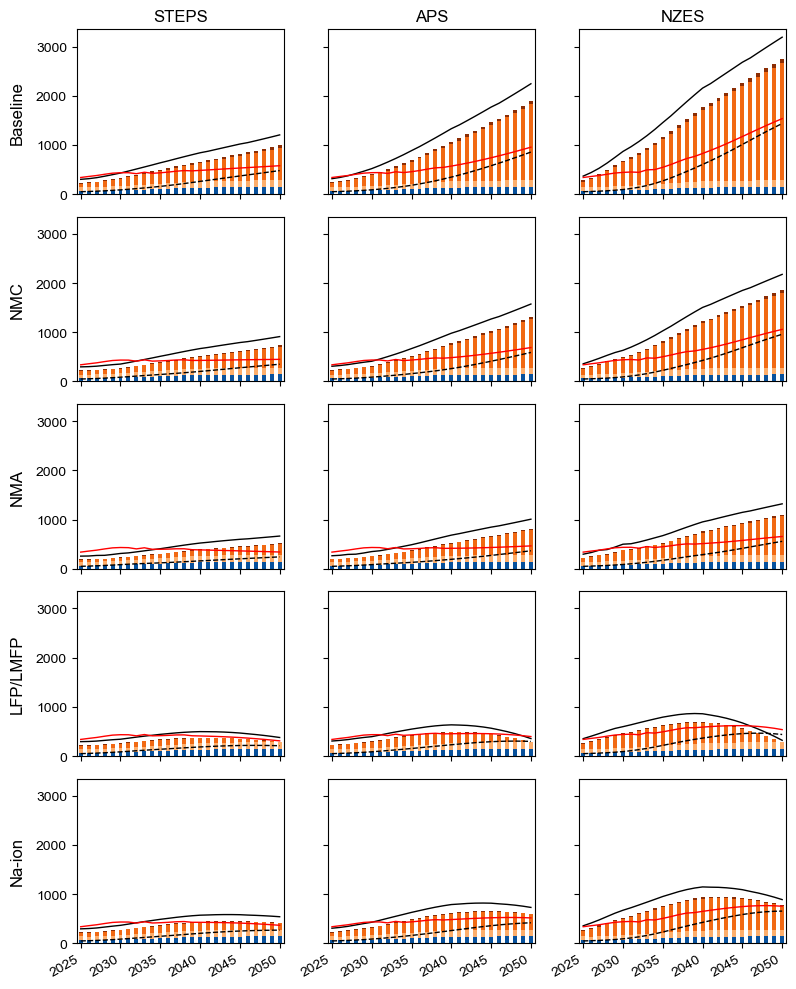

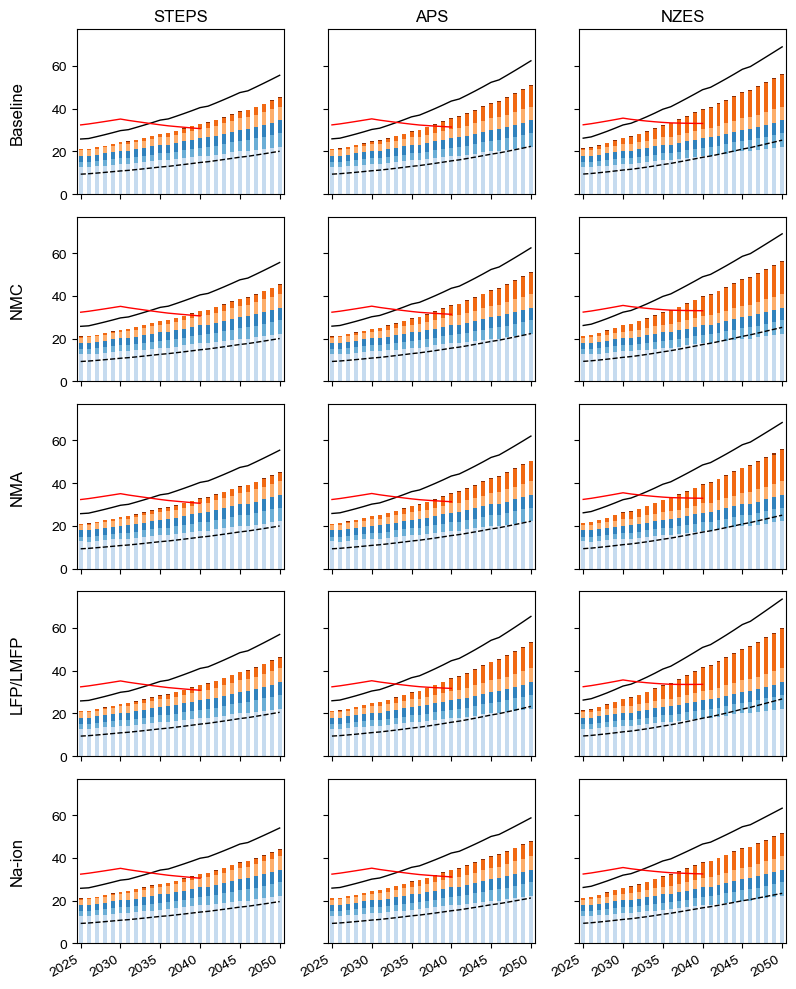

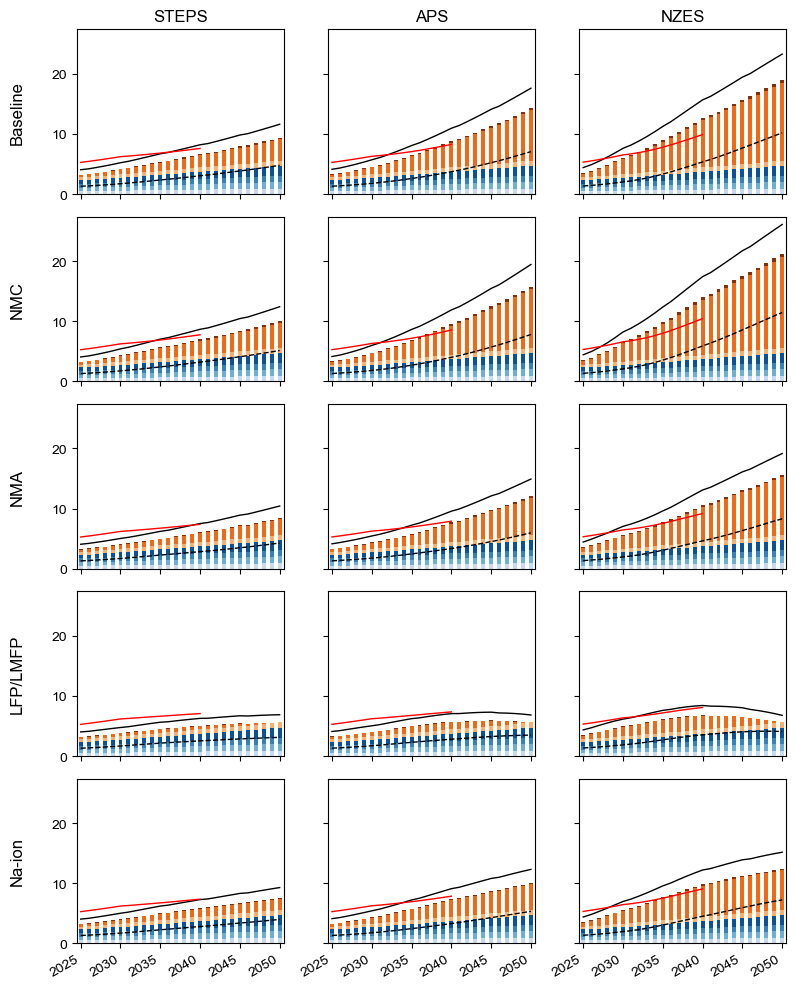

In [43]:
def plot_flow_for_scenarios(material):
    
    fig, axes = plt.subplots(len(Battery_Scenarios),len(IEA_Scenarios), figsize=(8,10), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, iea_sce in enumerate(IEA_Scenarios):
            
            lt='Constant'
            seg_sce='Baseline'
            b_size='Larger'
            
            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
            
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
            #df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            #df_all_sector_stock_2 = reconstruct_sector(df_all_sector_stock)
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='Constant', process_sce='Constant')            
            df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            
            plot_flow_for_a_scenario(axes[i,j], df_all_sector_inflow_2, df_all_sector_outflow_2, material)
            plot_supply_balance_for_a_scenario(axes[i,j], df_s_demand, df_pri_s_p, material)
            
            axes[i,j].set_xlabel('')
            axes[i,j].set_xticks(np.arange(0,26,5))
            axes[i,j].set_xticklabels(np.arange(2025,2051,5), rotation=30, ha='right')  # 设置刻度标签
            if i == 0:
                axes[i,j].set_title(iea_sce)
            if j == 0:
                axes[i, j].annotate(b_sce, xy=(-0.25, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    #为最后一个子图添加 legend
    #handles, labels = axes[-1,-1].get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02), frameon=False)
    
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_Year_'+material+'.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.show()
    

## unit: Mt
plot_flow_for_scenarios(material='Cobalt')
plot_flow_for_scenarios(material='Copper')
plot_flow_for_scenarios(material='Nickel')

#### Plot cummulative

In [44]:
def extract_cum_supply_demand():
    
    df_cum_primary_supply = pd.DataFrame(index=pd.MultiIndex.from_product([IEA_Scenarios,Battery_Scenarios],names=['IEA Scenarios','Battery_Scenarios']),
                                         columns=Materials)
    df_cum_secondary_supply = df_cum_primary_supply.copy()
    df_cum_inflow = pd.DataFrame(index=pd.MultiIndex.from_product([IEA_Scenarios,Battery_Scenarios], names=['IEA Scenarios','Battery_Scenarios']),
                                 columns=pd.MultiIndex.from_product([Materials,Agg_Sectors], names=['Material','Sector']))
    
    for iea_sce in IEA_Scenarios:
        for b_sce in Battery_Scenarios:
        
            lt='Constant'
            seg_sce='Baseline'
            b_size='Larger'
            
            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
            
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
            
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='Constant', process_sce='Constant')            
            #df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            
            ## fill in cum supply / demand
            for material in Materials:
                
                for sector in Agg_Sectors:
                    if sector in df_all_sector_inflow_2[material].columns:
                        df_cum_inflow.at[(iea_sce,b_sce),(material,sector)] = df_all_sector_inflow_2[material].T.groupby('Sector').sum().T[sector].sum() / 1000 ## from kt to Mt
                df_cum_inflow.fillna(value=0, inplace=True)
                
                df_cum_primary_supply.at[(iea_sce,b_sce),material] = df_s_demand.loc[2020:, material+'_Primary'].sum() / 1000  ## from kt to Mt
                df_cum_secondary_supply.at[(iea_sce,b_sce),material] = df_s_demand.loc[2020:, material+'_Secondary_Low'].sum() / 1000  + df_s_demand.loc[2020:, material+'_Secondary_High'].sum() / 1000 ## from kt to Mt   ######################********************
                

    return df_cum_inflow, df_cum_primary_supply, df_cum_secondary_supply


## unit: Mt
df_base_cum_inflow, df_base_cum_primary_supply, df_base_cum_secondary_supply = extract_cum_supply_demand()
df_base_cum_inflow.loc['NZES',:]

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\1547609021.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cum_inflow.fillna(value=0, inplace=True)
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\1547609021.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.405973792787243' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cum_inflow.at[(iea_sce,b_sce),(material,sector)] = df_all_sector_inflow_2[material].T.groupby('Sector').sum().T[sector].sum() / 1000 ## from kt to Mt
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_11888\1547609021.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a

Material                             Cobalt                 \
Sector            Building & Infrastructure Transportation   
Battery_Scenarios                                            
Baseline                                  0              0   
NMC                                       0              0   
NMA                                       0              0   
LFP/LMFP                                  0              0   
Na-ion                                    0              0   

Material                                                              \
Sector            Industrial Equipment Metal Goods & Others    B-CEs   
Battery_Scenarios                                                      
Baseline                             0             2.876392  2.94825   
NMC                                  0             2.876392  2.94825   
NMA                                  0             2.876392  2.94825   
LFP/LMFP                             0             2.876392  2.94825   
Na-ion                               0             2.876392  2.94825   

Material                                                  Nickel  \
Sector                 B-EVs     B-ESS Building & Infrastructure   
Battery_Scenarios                                                  
Baseline           30.997457  1.412863                 18.405974   
NMC                19.927853  0.926526                 18.405974   
NMA                10.532947  0.499603                 18.405974   
LFP/LMFP            7.400363  0.428074                 18.405974   
Na-ion             12.516979  0.645638                 18.405974   

Material                                               ...            \
Sector            Transportation Industrial Equipment  ...     B-CEs   
Battery_Scenarios                                      ...             
Baseline               21.758868            21.533862  ...  17.31653   
NMC                    21.758868            21.533862  ...  17.31653   
NMA                    21.758868            21.533862  ...  17.31653   
LFP/LMFP               21.758868            21.533862  ...  17.31653   
Na-ion                 21.758868            21.533862  ...  17.31653   

Material                                                   Copper  \
Sector                  B-EVs     B-ESS Building & Infrastructure   
Battery_Scenarios                                                   
Baseline           167.154648  7.618904                439.183817   
NMC                195.413909  8.860616                439.183817   
NMA                126.974087  5.904584                439.183817   
LFP/LMFP            39.906661  2.308400                439.183817   
Na-ion             105.848421  5.073748                439.183817   

Material                                                                    \
Sector            Transportation Industrial Equipment Metal Goods & Others   
Battery_Scenarios                                                            
Baseline               99.739408            109.96293                    0   
NMC                    99.739408            109.96293                    0   
NMA                    99.739408            109.96293                    0   
LFP/LMFP               99.739408            109.96293                    0   
Na-ion                 99.739408            109.96293                    0   

Material                                              
Sector                  B-CEs       B-EVs      B-ESS  
Battery_Scenarios                                     
Baseline           106.933198  191.094744   8.710093  
NMC                106.933198  192.744589   8.782610  
NMA                106.933198  186.398369   8.509000  
LFP/LMFP           106.933198  226.427618  10.184657  
Na-ion             106.933198  147.965815   6.919575  

[5 rows x 21 columns]

In [45]:
df_base_cum_inflow.loc['NZES','Cobalt'].sum(axis=1)

Battery_Scenarios
Baseline    38.234962
NMC         26.679021
NMA         16.857191
LFP/LMFP    13.653079
Na-ion      18.987259
dtype: float64

In [46]:
df_base_cum_inflow.loc['NZES','Nickel'].sum(axis=1)

Battery_Scenarios
Baseline    282.208091
NMC         311.709065
NMA         240.313211
LFP/LMFP    149.649601
Na-ion      218.356709
dtype: float64

In [47]:
df_base_cum_inflow.loc['NZES','Copper'].sum(axis=1)

Battery_Scenarios
Baseline    955.624190
NMC         957.346551
NMA         950.726722
LFP/LMFP    992.431629
Na-ion      910.704744
dtype: float64

In [48]:
(df_base_cum_inflow['Cobalt','B-EVs']+ df_base_cum_inflow['Cobalt','B-ESS']) / df_base_cum_inflow['Cobalt'].sum(axis=1) * 100

IEA Scenarios  Battery_Scenarios
STEPS          Baseline             61.498067
               NMC                  50.845530
               NMA                  35.511021
               LFP/LMFP             29.089823
               Na-ion               40.071193
APS            Baseline             76.021554
               NMC                  67.106206
               NMA                  51.853019
               LFP/LMFP             41.811251
               Na-ion               55.497361
NZES           Baseline             84.766188
               NMC                  78.167706
               NMA                  65.447137
               LFP/LMFP             57.338250
               Na-ion               69.323417
dtype: float64

In [49]:
(df_base_cum_inflow['Nickel','B-EVs']+ df_base_cum_inflow['Nickel','B-ESS']) / df_base_cum_inflow['Nickel'].sum(axis=1) * 100

IEA Scenarios  Battery_Scenarios
STEPS          Baseline             31.832663
               NMC                  35.270308
               NMA                  26.323644
               LFP/LMFP             10.709198
               Na-ion               23.074705
APS            Baseline             48.103203
               NMC                  52.000280
               NMA                  41.310705
               LFP/LMFP             17.360411
               Na-ion               36.748129
NZES           Baseline             61.930737
               NMC                  65.533713
               NMA                  55.293952
               LFP/LMFP             28.209271
               Na-ion               50.798608
dtype: float64

In [50]:
(df_base_cum_inflow['Copper','B-EVs']+ df_base_cum_inflow['Copper','B-ESS']) / df_base_cum_inflow['Copper'].sum(axis=1) * 100

IEA Scenarios  Battery_Scenarios
STEPS          Baseline              7.053217
               NMC                   7.109044
               NMA                   6.895276
               LFP/LMFP              8.221668
               Na-ion                5.587633
APS            Baseline             13.090517
               NMC                  13.188470
               NMA                  12.809290
               LFP/LMFP             15.176224
               Na-ion               10.396770
NZES           Baseline             20.908307
               NMC                  21.050601
               NMA                  20.500883
               LFP/LMFP             23.841670
               Na-ion               17.007201
dtype: float64

In [51]:
df_base_cum_primary_supply

Cobalt      Nickel      Copper
IEA Scenarios Battery_Scenarios                                   
STEPS         Baseline           13.135241  122.486016  631.762887
              NMC                10.472836  129.342917  632.176616
              NMA                 8.210935  112.648384  630.580564
              LFP/LMFP            6.897146   89.592792  640.932258
              Na-ion              8.207756  106.546193  620.534753
APS           Baseline           21.383684  166.008175  681.695477
              NMC                15.730999  180.323471  682.545548
              NMA                10.942812  145.324795  679.242978
              LFP/LMFP            7.961718   96.043583  700.973539
              Na-ion             10.769423   132.04726  658.039052
NZES          Baseline           31.976523  224.859472  752.442115
              NMC                22.500226  249.191953  753.905045
              NMA                14.478673  189.788144  748.239028
              LFP/LMFP            9.714825  107.599115  785.072047
              Na-ion             14.387668  168.011222  712.461243

In [52]:
df_base_cum_secondary_supply

Cobalt      Nickel      Copper
IEA Scenarios Battery_Scenarios                                   
STEPS         Baseline             5.91471   72.944896  364.542379
              NMC                 4.733006   76.492888  364.728037
              NMA                 3.696393   68.114948  364.032642
              LFP/LMFP            3.921279   59.259277   368.07683
              Na-ion              4.393151   66.457666  360.279928
APS           Baseline            8.571489   91.145509  383.867932
              NMC                 6.443396   97.777492  384.221164
              NMA                 4.607488   81.941226  382.880411
              LFP/LMFP            4.883559   64.701585  390.824197
              Na-ion              5.746886   78.563056  375.447919
NZES          Baseline           14.181868  125.498586  418.420619
              NMC                10.090238  137.855562  419.068826
              NMA                  6.58644  108.415969  416.620095
              LFP/LMFP            7.161041   77.123862   430.92941
              Na-ion              8.810827  102.527153   403.31194

In [53]:
df_base_cum_primary_supply + df_base_cum_secondary_supply

Cobalt      Nickel       Copper
IEA Scenarios Battery_Scenarios                                    
STEPS         Baseline           19.049951  195.430913   996.305266
              NMC                15.205842  205.835806   996.904653
              NMA                11.907328  180.763332   994.613207
              LFP/LMFP           10.818425  148.852069  1009.009088
              Na-ion             12.600907  173.003859   980.814681
APS           Baseline           29.955172  257.153684  1065.563409
              NMC                22.174395  278.100963  1066.766712
              NMA                  15.5503  227.266021  1062.123389
              LFP/LMFP           12.845277  160.745168  1091.797736
              Na-ion             16.516309  210.610316  1033.486971
NZES          Baseline           46.158391  350.358058  1170.862734
              NMC                32.590463  387.047515  1172.973871
              NMA                21.065113  298.204113  1164.859123
              LFP/LMFP           16.875866  184.722978  1216.001457
              Na-ion             23.198495  270.538375  1115.773183

In [54]:
df_base_cum_secondary_supply / (df_base_cum_primary_supply + df_base_cum_secondary_supply)*100

Cobalt     Nickel     Copper
IEA Scenarios Battery_Scenarios                                 
STEPS         Baseline           31.048428  37.325158  36.589426
              NMC                31.126234   37.16209   36.58605
              NMA                31.043011  37.681839  36.600423
              LFP/LMFP           36.246304  39.810852   36.47904
              Na-ion             34.863768  38.413979  36.732722
APS           Baseline           28.614386  35.443983  36.024879
              NMC                 29.05782  35.158991  36.017356
              NMA                29.629575  36.055203  36.048581
              LFP/LMFP           38.018325  40.251029  35.796392
              Na-ion             34.795222  37.302568  36.328268
NZES          Baseline           30.724355  35.820094  35.736095
              NMC                30.960707  35.617219  35.727038
              NMA                31.267052  36.356296  35.765707
              LFP/LMFP            42.43362  41.751093  35.438231
              Na-ion             37.980165  37.897453  36.146409

Battery_Scenarios
Baseline    0.318327
NMC         0.352703
NMA         0.263236
LFP/LMFP    0.107092
Na-ion      0.230747
dtype: float64
Battery_Scenarios
Baseline    0.481032
NMC         0.520003
NMA         0.413107
LFP/LMFP    0.173604
Na-ion      0.367481
dtype: float64
Battery_Scenarios
Baseline    0.619307
NMC         0.655337
NMA         0.552940
LFP/LMFP    0.282093
Na-ion      0.507986
dtype: float64


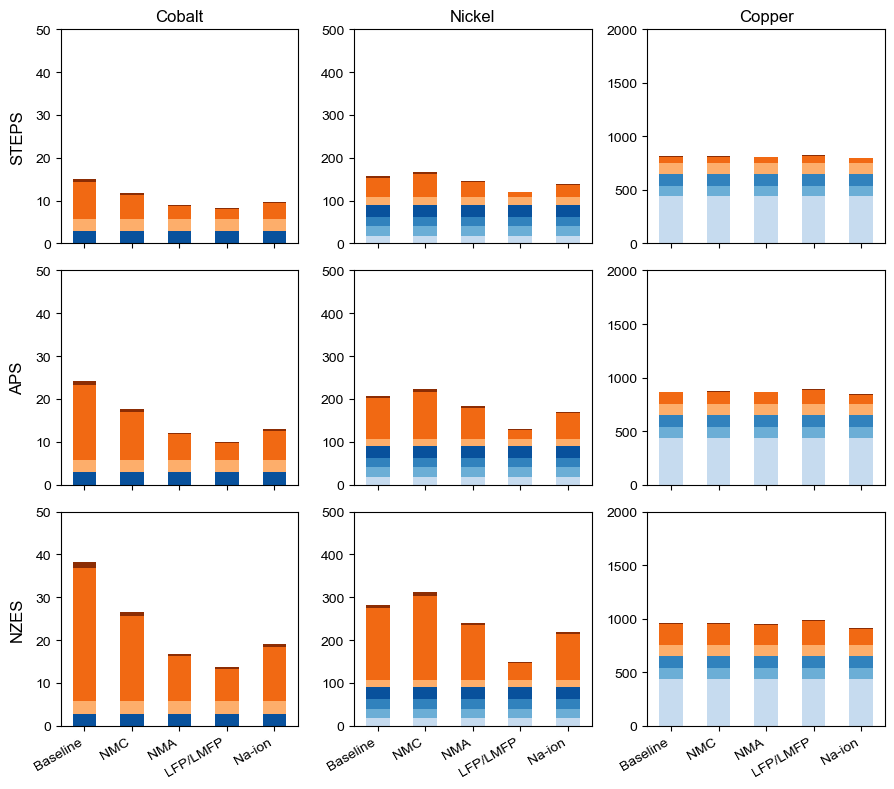

In [55]:
def plot_cum_inflow(df):
    
    fig, axes = plt.subplots(3,3, figsize=(9,8), sharex=True)
    
    for i, iea_sce in enumerate(IEA_Scenarios):
        for j, material in enumerate(Materials):
            
            if material == 'Copper':
                Agg_Sectors = Cu_Agg_Sectors
                Agg_Sector_Colors = Cu_Agg_Sector_Colors
            elif material == 'Nickel':
                Agg_Sectors = Ni_Agg_Sectors
                Agg_Sector_Colors = Ni_Agg_Sector_Colors
            elif material == 'Cobalt':
                Agg_Sectors = Co_Agg_Sectors
                Agg_Sector_Colors = Co_Agg_Sector_Colors

            df_plot = df.loc[(iea_sce),(material)]
            df_plot = df_plot[Agg_Sectors]
            df_plot['X'] = np.arange(0, len(Battery_Scenarios))
            df_plot.plot.bar(ax=axes[i,j], x='X', y=Agg_Sectors, color=Agg_Sector_Colors, stacked=True, legend=False)
            
            if material == 'Copper':
                axes[i,j].set_ylim(0,2000)
            elif material == 'Nickel':
                axes[i,j].set_ylim(0,500)
                #axes[i,j].set_yticks([0, 100, 200, 300, 400, 500])
                df_temp = df_plot.drop(columns=['X'])
                print((df_temp['B-EVs']+df_temp['B-ESS']) / df_temp.sum(axis=1))
            elif material == 'Cobalt':
                axes[i,j].set_ylim(0,50)
                
            axes[i,j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
            axes[i,j].set_xlabel('')
            
            if i == 0:
                axes[i,j].set_title(material)
            if j == 0:
                axes[i,j].annotate(iea_sce, xy=(-0.15, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_All_Cum_Inflow.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_All_Cum_Inflow.svg', bbox_inches='tight', format='svg')
    plt.show()
    
    
df_temp = plot_cum_inflow(df_base_cum_inflow)
df_temp

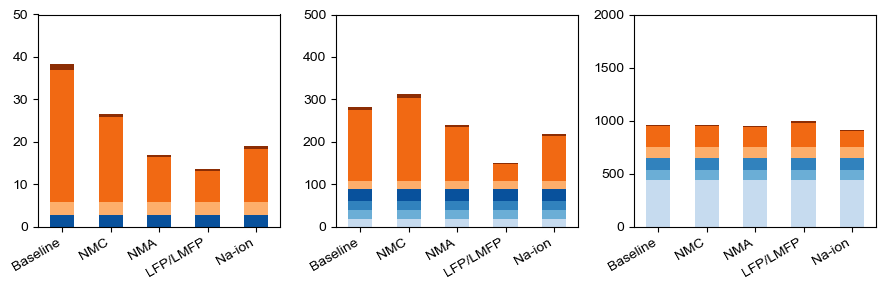

In [56]:
def plot_cum_inflow(df):
    
    fig, axes = plt.subplots(1,3, figsize=(9,3), sharex=True)
    
    iea_sce = 'NZES'
    for j, material in enumerate(Materials):

        if material == 'Copper':
            Agg_Sectors = Cu_Agg_Sectors
            Agg_Sector_Colors = Cu_Agg_Sector_Colors
            axes[j].set_ylim(0,2000)
        elif material == 'Nickel':
            Agg_Sectors = Ni_Agg_Sectors
            Agg_Sector_Colors = Ni_Agg_Sector_Colors
            axes[j].set_ylim(0,500)
        elif material == 'Cobalt':
            axes[j].set_ylim(0,50)
            Agg_Sectors = Co_Agg_Sectors
            Agg_Sector_Colors = Co_Agg_Sector_Colors
            
        df_plot = df.loc[(iea_sce),(material)]
        df_plot = df_plot[Agg_Sectors]
        df_plot['X'] = np.arange(0, len(Battery_Scenarios))
        df_plot.plot.bar(ax=axes[j], x='X', y=Agg_Sectors, color=Agg_Sector_Colors, stacked=True, legend=False)

        axes[j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
        axes[j].set_xlabel('')
        #axes[j].set_title(material)
        
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_NZES_Cum_Inflow.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_NZES_Cum_Inflow.svg', bbox_inches='tight', format='svg')
    plt.show()
    
    
plot_cum_inflow(df_base_cum_inflow)

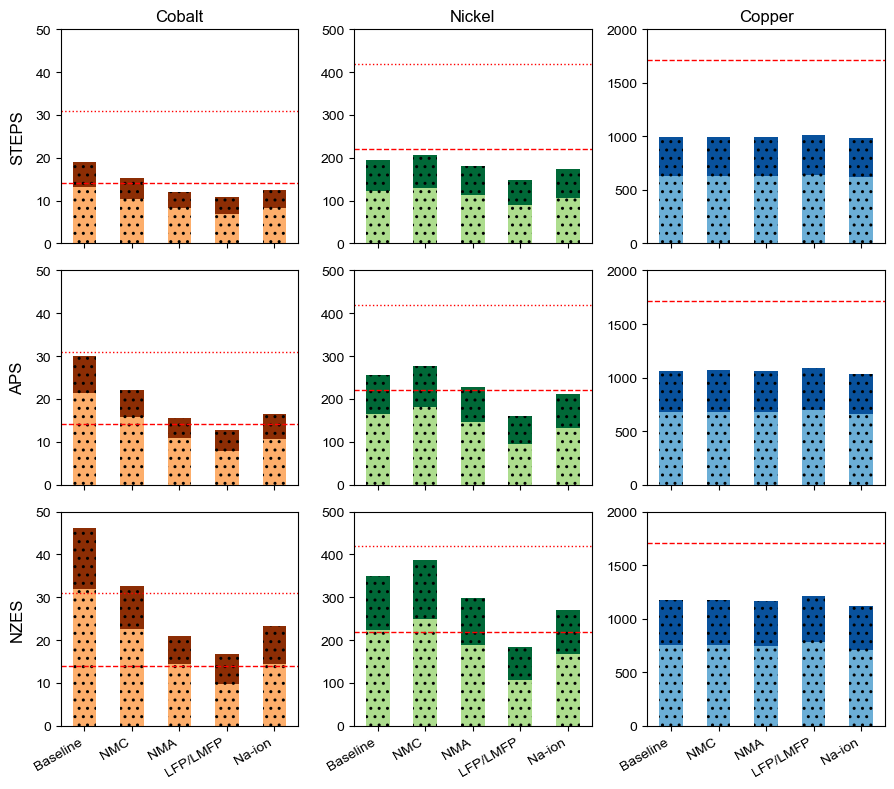

In [57]:
def plot_cum_supply(df_pri, df_sec):
    
    fig, axes = plt.subplots(3,3, figsize=(9,8), sharex=True)
    
    for i, iea_sce in enumerate(IEA_Scenarios):
        for j, material in enumerate(Materials):
            if material == 'Copper':
                Colors = ['#6BAED6','#08519C']
            elif material == 'Nickel':
                Colors = ['#ADDD8E','#006837']
            elif material == 'Cobalt':
                Colors = ['#FDAE6B','#8C2D04']
                
            df_plot = pd.DataFrame(index=Battery_Scenarios, columns=['Primary','Secondary'])
            df_plot.Primary = df_pri.loc[(iea_sce),(material)]
            df_plot.Secondary = df_sec.loc[(iea_sce),(material)]
            
            df_plot['X'] = np.arange(0, len(Battery_Scenarios))
            df_plot.plot.bar(ax=axes[i,j], x='X', color=Colors, stacked=True, legend=False, hatch='..')
            
            if material == 'Copper':
                axes[i,j].set_ylim(0,2000)
                Cu_reserve = 1711.216062  ## Mt
                Cu_resource =  3062.496368  ## Mt
                #axes[i,j].axhline(Cu_resource, color='r', lw=1, linestyle=':')
                axes[i,j].axhline(Cu_reserve, color='r', lw=1, linestyle='--')
                
            elif material == 'Nickel':
                axes[i,j].set_ylim(0,500)
                #axes[i,j].set_yticks([0, 100, 200, 300, 400, 500])
                Ni_reserve = 219.848463  ## Mt
                Ni_resource =  419.859742 ## Mt
                axes[i,j].axhline(Ni_resource, color='r', lw=1, linestyle=':')
                axes[i,j].axhline(Ni_reserve, color='r', lw=1, linestyle='--')
                
            elif material == 'Cobalt':
                axes[i,j].set_ylim(0,50)
                Co_reserve = 14.061897    ## Mt
                Co_resource =  30.986222 ## Mt
                axes[i,j].axhline(Co_resource, color='r', lw=1, linestyle=':')
                axes[i,j].axhline(Co_reserve, color='r', lw=1, linestyle='--')
                Co_pri_supply_SP = 7.3083112492543  ## Mt
                #axes[i,j].axhline(Co_pri_supply_SP, color='r', lw=1, linestyle='-')
                
            axes[i,j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
            axes[i,j].set_xlabel('')
                
            if i == 0:
                axes[i,j].set_title(material)
            if j == 0:
                axes[i,j].annotate(iea_sce, xy=(-0.15, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_All_Cum_Supply.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_All_Cum_Supply.svg', bbox_inches='tight', format='svg')
    plt.show()
            
        
plot_cum_supply(df_base_cum_primary_supply, df_base_cum_secondary_supply)

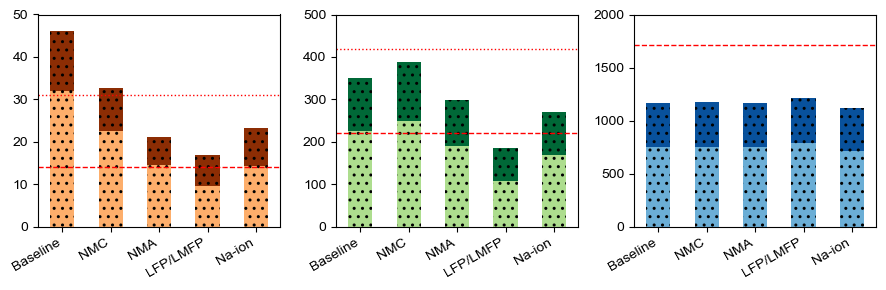

In [58]:
def plot_cum_supply(df_pri, df_sec):
    
    fig, axes = plt.subplots(1,3, figsize=(9,3), sharex=True)
    
    iea_sce = 'NZES'
    for j, material in enumerate(Materials):
        if material == 'Copper':
            Colors = ['#6BAED6','#08519C']
        elif material == 'Nickel':
            Colors = ['#ADDD8E','#006837']
        elif material == 'Cobalt':
            Colors = ['#FDAE6B','#8C2D04']

        df_plot = pd.DataFrame(index=Battery_Scenarios, columns=['Primary','Secondary'])
        df_plot.Primary = df_pri.loc[(iea_sce),(material)]
        df_plot.Secondary = df_sec.loc[(iea_sce),(material)]

        df_plot['X'] = np.arange(0, len(Battery_Scenarios))
        df_plot.plot.bar(ax=axes[j], x='X', color=Colors, stacked=True, legend=False, hatch='..')

        if material == 'Copper':
            axes[j].set_ylim(0,2000)
            Cu_reserve = 1711.216062  ## Mt
            Cu_resource =  3062.496368  ## Mt
            #axes[j].axhline(Cu_resource, color='r', lw=1, linestyle=':')
            axes[j].axhline(Cu_reserve, color='r', lw=1, linestyle='--')
            
        elif material == 'Nickel':
            axes[j].set_ylim(0,500)
            #axes[j].set_yticks([0, 100, 200, 300, 400,500])
            Ni_reserve = 219.848463  ## Mt
            Ni_resource =  419.859742 ## Mt
            axes[j].axhline(Ni_resource, color='r', lw=1, linestyle=':')
            axes[j].axhline(Ni_reserve, color='r', lw=1, linestyle='--')
            
        elif material == 'Cobalt':
            axes[j].set_ylim(0,50)
            #axes[j].set_yticks([0,20,40,60,80])
            Co_reserve = 14.061897    ## Mt
            Co_resource =  30.986222 ## Mt
            axes[j].axhline(Co_resource, color='r', lw=1, linestyle=':')
            axes[j].axhline(Co_reserve, color='r', lw=1, linestyle='--')
            Co_pri_supply_SP = 7.3083112492543  ## Mt
            #axes[j].axhline(Co_pri_supply_SP, color='r', lw=1, linestyle='-')

        axes[j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
        axes[j].set_xlabel('')
        #axes[j].set_title(material)
    
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_NZES_Cum_Supply.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_NZES_Cum_Supply.svg', bbox_inches='tight', format='svg')
    plt.show()
            
        
plot_cum_supply(df_base_cum_primary_supply, df_base_cum_secondary_supply)

In [59]:
with pd.ExcelWriter(file_path + 'Scenarios/plot_Strategy/Baseline/Baseline_extended_Fig3.xlsx') as writer:
    
    df_base_cum_inflow.to_excel(excel_writer = writer, sheet_name='Cum_inflow')
    df_base_cum_primary_supply.to_excel(excel_writer = writer, sheet_name='Cum_primary')
    df_base_cum_secondary_supply.to_excel(excel_writer = writer, sheet_name='Cum_secondary')

In [60]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 1分钟 16秒
